# Full Dataset Study
**ShipmentSure — Predicting On-Time Delivery**

A holistic structural study of the entire dataset before deeper engineering:
- Shape, info, describe
- Skewness, value frequencies
- Business-facing summaries (mode-wise, warehouse-wise, delivery-rate-wise)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Shape: (1000, 12)
Rows: 1000, Columns: 12


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Full info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   1000 non-null   int64 
 1   Warehouse_block      1000 non-null   object
 2   Mode_of_Shipment     1000 non-null   object
 3   Customer_care_calls  1000 non-null   int64 
 4   Customer_rating      1000 non-null   int64 
 5   Cost_of_the_Product  1000 non-null   int64 
 6   Prior_purchases      1000 non-null   int64 
 7   Product_importance   1000 non-null   object
 8   Gender               1000 non-null   object
 9   Discount_offered     1000 non-null   int64 
 10  Weight_in_gms        1000 non-null   int64 
 11  Reached.on.Time_Y.N  1000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 93.9+ KB


In [4]:
# Summary statistics
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,4.523000,2.981000,200.316000,5.984000,31.987000,3501.413000,0.505000
std,288.819436,1.731031,1.424313,62.730178,2.574174,18.506737,1407.924646,0.500225
min,1.000000,2.000000,1.000000,90.000000,2.000000,1.000000,1005.000000,0.000000
25%,250.750000,3.000000,2.000000,146.000000,4.000000,16.000000,2271.250000,0.000000
50%,500.500000,5.000000,3.000000,202.500000,6.000000,32.000000,3544.000000,1.000000
75%,750.250000,6.000000,4.000000,254.000000,8.000000,48.000000,4683.250000,1.000000
max,1000.000000,7.000000,5.000000,309.000000,10.000000,64.000000,5988.000000,1.000000


In [5]:
# Skewness of numeric features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Skewness per numeric column:")
print(df[num_cols].skew().sort_values(ascending=False))

Skewness per numeric column:
Discount_offered       0.035434
Customer_rating        0.027258
ID                     0.000000
Prior_purchases       -0.016479
Reached.on.Time_Y.N   -0.020031
Cost_of_the_Product   -0.020105
Customer_care_calls   -0.028389
Weight_in_gms         -0.058986
dtype: float64


In [6]:
# Value frequency proportions for categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("Category proportions:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).round(3))

Category proportions:

Warehouse_block:
Warehouse_block
C    0.214
D    0.213
A    0.197
F    0.196
B    0.180
Name: proportion, dtype: float64

Mode_of_Shipment:
Mode_of_Shipment
Road      0.345
Ship      0.333
Flight    0.322
Name: proportion, dtype: float64

Product_importance:
Product_importance
low       0.353
medium    0.325
high      0.322
Name: proportion, dtype: float64

Gender:
Gender
F    0.516
M    0.484
Name: proportion, dtype: float64


In [7]:
# Business summary: On-time rate by Mode of Shipment
mode_summary = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].agg(['mean', 'count']).rename(
    columns={'mean': 'On_Time_Rate', 'count': 'Total_Shipments'}
).reset_index()
mode_summary['On_Time_Rate'] = mode_summary['On_Time_Rate'].round(3)
print("On-time delivery rate by Mode of Shipment:")
print(mode_summary)

On-time delivery rate by Mode of Shipment:
  Mode_of_Shipment  On_Time_Rate  Total_Shipments
0           Flight         0.460              322
1             Road         0.519              345
2             Ship         0.535              333


In [8]:
# Business summary: On-time rate by Warehouse Block
warehouse_summary = df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].agg(['mean', 'count']).rename(
    columns={'mean': 'On_Time_Rate', 'count': 'Total_Shipments'}
).reset_index()
warehouse_summary['On_Time_Rate'] = warehouse_summary['On_Time_Rate'].round(3)
print("On-time delivery rate by Warehouse Block:")
print(warehouse_summary)

On-time delivery rate by Warehouse Block:
  Warehouse_block  On_Time_Rate  Total_Shipments
0               A         0.569              197
1               B         0.494              180
2               C         0.523              214
3               D         0.474              213
4               F         0.464              196


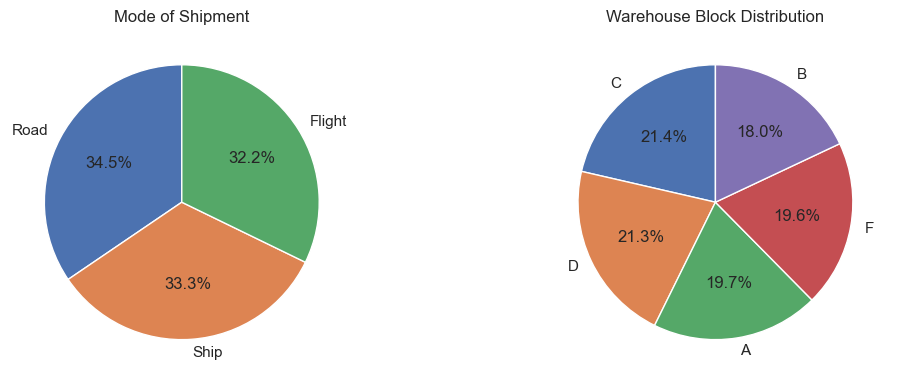

In [9]:
# Pie chart: Mode of Shipment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Mode_of_Shipment'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Mode of Shipment')
axes[0].set_ylabel('')

df['Warehouse_block'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Warehouse Block Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

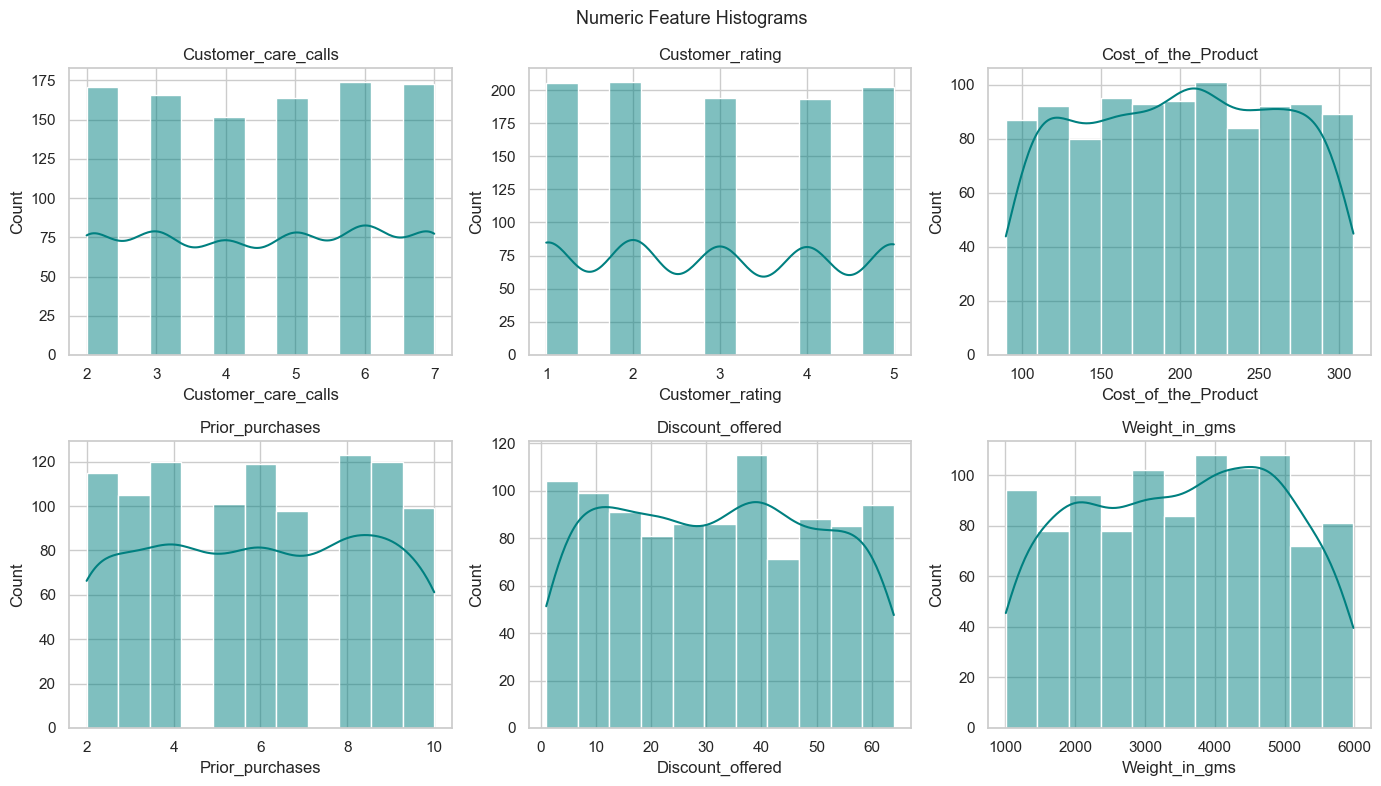

In [10]:
# Histograms for numeric features
num_plot_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Numeric Feature Histograms', fontsize=13)

for idx, col in enumerate(num_plot_cols):
    ax = axes[idx // 3][idx % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='teal')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [11]:
# Mean delivery outcome by product importance
importance_summary = df.groupby('Product_importance')['Reached.on.Time_Y.N'].mean()
print("On-time rate by Product Importance:")
print(importance_summary)

On-time rate by Product Importance:
Product_importance
high      0.531056
low       0.509915
medium    0.473846
Name: Reached.on.Time_Y.N, dtype: float64
